# Example № 01. Основы языковых моделей

**Вариант:** готовый example  
**Учебный профиль:** Harbor Town  
**Время:** 6 академических часов  
**Seed:** 42

Перед работой выберите один из равноправных маршрутов: [компактную лекцию](lecture_01_language_model_basics_compact.md) с доступным первым объяснением или [полный лонгрид](lecture_01_language_model_basics.md) с подробными разборами. Затем работайте с ячейками по порядку. Этот notebook оставляет рядом с кодом только то пояснение, которое нужно для очередного шага. Example показывает те же API, имена функций и порядок действий на других данных; сопоставьте его ячейки §1–§6 со student-вариантом, но решайте Greenfield самостоятельно.

**Навигация:** [страница ЛР](README.md) · [компактная лекция](lecture_01_language_model_basics_compact.md) · [полный лонгрид](lecture_01_language_model_basics.md) · [Harbor example](lab_01_example.ipynb) · [student](lab_01_student.ipynb) · [teacher](lab_01_teacher.ipynb)


## Подготовка

Этот example автономен: данные сценария встроены в следующую ячейку; он работает без чтения файлов, сети и ячеек других notebooks.


In [ ]:
from __future__ import annotations

from collections import Counter, defaultdict
from copy import deepcopy
import json
import math
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

SCENARIO = {'id': 'harbor-town', 'title': 'Harbor Town', 'description': 'Автономный готовый пример о гавани, саде и мастерской.', 'classification': {'class_names': ['Harbor', 'Orchard', 'Workshop'], 'documents': [{'label': 'Harbor', 'text': 'boats enter the quiet harbor'}, {'label': 'Harbor', 'text': 'sailors watch the harbor lights'}, {'label': 'Harbor', 'text': 'the captain guides boats to shore'}, {'label': 'Harbor', 'text': 'the harbor bell rings at dawn'}, {'label': 'Orchard', 'text': 'apples grow in the green orchard'}, {'label': 'Orchard', 'text': 'farmers pick ripe apples from trees'}, {'label': 'Orchard', 'text': 'the orchard gate opens at dawn'}, {'label': 'Orchard', 'text': 'baskets carry sweet apples home'}, {'label': 'Workshop', 'text': 'workers build wooden chairs in the workshop'}, {'label': 'Workshop', 'text': 'the mechanic repairs old engines'}, {'label': 'Workshop', 'text': 'tools fill the workshop table'}, {'label': 'Workshop', 'text': 'the worker paints a wooden chair'}], 'new_documents': ['harbor lights guide boats', 'ripe apples fill baskets', 'tools repair engines'], 'order_examples': ['harbor bell rings', 'rings bell harbor']}, 'embedding': {'lines': ['the sailor watches the harbor lights', 'the captain watches the harbor lights', 'the sailor visits the lighthouse', 'the captain visits the lighthouse', 'the sailor guides the boat', 'the captain guides the ship', 'the sailor sees the harbor bell', 'the captain sees the harbor bell', 'boats enter the quiet harbor', 'ships enter the quiet harbor'], 'query_words': ['sailor', 'captain'], 'window_size': 2, 'embedding_dim': 12, 'steps': 350, 'learning_rate': 0.04}, 'bpe': {'corpus': ['harbor harbor bell harbor lights', 'sailor sails past the harbor', 'orchard apples workshop tools'], 'vocab_size': 28, 'probe_words': ['harbor', 'sailboat7']}, 'language_model': {'n': 3, 'train_text': 'the harbor bell rings at dawn the harbor bell rings at dusk the sailor sees harbor lights the harbor lights guide sailors home', 'test_text': 'the harbor bell rings at dusk', 'known_context': ['the', 'harbor'], 'unknown_context': ['silent', 'harbor'], 'generation_context': ['the', 'harbor'], 'generation_length': 5}, 'evaluation': {'reference': 'the harbor bell rings at dawn', 'candidates': [{'name': 'A', 'text': 'the bell rings at dawn near harbor'}, {'name': 'B', 'text': 'sailors watch the quiet sea'}], 'elo_names': ['Harbor-LM', 'Orchard-LM', 'Workshop-LM'], 'elo_matches': [['Harbor-LM', 'Orchard-LM', 1.0], ['Harbor-LM', 'Workshop-LM', 0.0], ['Orchard-LM', 'Workshop-LM', 1.0]]}, 'portfolio': {'document': 'harbor lights guide boats', 'embedding_word': 'sailor', 'bpe_word': 'sailboat7', 'lm_context': ['the', 'harbor'], 'num_tokens': 5, 'candidate_name': 'A'}, 'sandbox': {'document': 'zephyrs quizzically', 'embedding_word': 'unseenword', 'bpe_word': '', 'lm_context': ['silent', 'harbor'], 'num_tokens': 3, 'perplexity_tokens': [], 'candidate': '', 'reference': ''}}


## Как проходить этот notebook

**Профиль:** Harbor Town. В Harbor example код уже готов: наблюдайте тот же путь данных на других словах и сопоставляйте его со student-вариантом, не перенося Harbor-числа в Greenfield-ответы.

1. Выполняйте §§1–6 строго сверху вниз: функции §1 нужны дальше, §2 использует BoW, §5 готовит PPL для §6.
2. Следующая ячейка после реализации — готовая контрольная проверка: запускайте её, но не переписывайте. Если она остановилась, исправьте текущую реализацию, а не переходите к следующему разделу.
3. §§1–2 образуют одну ветвь классификации документов. Skip-gram (§3), BPE (§4) и Count LM (§5) — самостоятельные учебные эксперименты, а не один конвейер; §6 оценивает их результаты разными способами.
4. Точные значения loss и ближайших слов могут немного отличаться между средами. Надёжные признаки готовности — форма тензора, диапазон числа, контрольное утверждение и объяснение ограничения метода.
5. После раздела прочитайте заполненный Harbor-разбор, сопоставьте ход с student-вариантом и не переносите Harbor-числа в Greenfield-ответ.

Для теории можно выбрать [компактную лекцию](lecture_01_language_model_basics_compact.md) или [полный лонгрид](lecture_01_language_model_basics.md): это равноправные маршруты разной глубины.


## 1. Мешок слов и n-граммы

Для объяснения выберите §1 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). В этом шаге нужно превратить строку в список токенов, назначить каждому токену устойчивый индекс и построить бинарный вектор. BoW хранит присутствие токена, но не его позицию; n-граммы ниже покажут, какую часть порядка можно вернуть.


### Маршрут §1: от строки к признакам

**Зачем.** Следующие разделы не умеют читать строку напрямую: им нужны устойчивые номера слов и бинарные признаки документа.

**Наблюдайте.** Готовый Harbor-код выполняет те же четыре действия на другом наборе слов; структура полностью совпадает со student-вариантом.

**Порядок.** 1) привести текст к нижнему регистру и выделить английские слова; 2) собрать уникальные токены всех документов и отсортировать их; 3) создать нулевой вектор длины словаря и поставить единицы только известным словам документа; 4) пройти по списку токенов скользящими окнами длины `n`.

**Не меняйте.** Данные профиля, порядок классов и контрольную ячейку после реализации.

**Что запустить.** Сразу следующую ячейку с DTM и тепловой картой.

**Готово, если.** В Harbor Town напечатаны словарь из 48 токенов и DTM `12 × 48`; BoW двух переставленных фраз совпадают, но их биграммы различаются.

**Если не получилось.** Проверьте, что BoW бинарный: повтор слова не создаёт `2`, а OOV-слово не получает новый индекс. Если DTM имеет другую ширину, словарь должен строиться один раз по всем документам.

**Что записать.** Наблюдение о разреженности, причина потери порядка и роль биграмм.


In [2]:
def tokenize(text: str) -> list[str]:
    """Возвращает строчные английские слова без пунктуации."""
    return re.findall(r"[a-z]+", text.lower())


def build_vocabulary(texts: list[str]) -> dict[str, int]:
    """Назначает индекс каждому уникальному токену в алфавитном порядке."""
    tokens = {token for text in texts for token in tokenize(text)}
    return {token: index for index, token in enumerate(sorted(tokens))}


def doc_to_bow(text: str, vocabulary: dict[str, int]) -> list[int]:
    """Строит бинарный BoW-вектор: 1 означает присутствие токена."""
    vector = [0] * len(vocabulary)
    for token in set(tokenize(text)):
        if token in vocabulary:
            vector[vocabulary[token]] = 1
    return vector


def make_ngrams(tokens: list[str], n: int) -> list[tuple[str, ...]]:
    if n < 1:
        raise ValueError("Порядок n-граммы должен быть положительным.")
    return [tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]


Размер словаря: 48
Форма DTM: (12, 48); плотность: 0.118


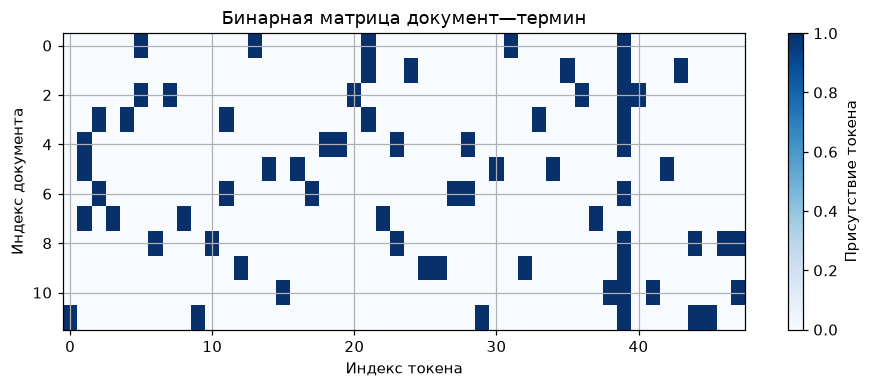

BoW совпадают: True
Биграммы первой фразы: [('harbor', 'bell'), ('bell', 'rings')]
Биграммы второй фразы: [('rings', 'bell'), ('bell', 'harbor')]


In [3]:
classification_data = SCENARIO["classification"]
CLASS_NAMES = classification_data["class_names"]
DOCS = [record["text"] for record in classification_data["documents"]]
class_to_id = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}
LABELS = torch.tensor(
    [class_to_id[record["label"]] for record in classification_data["documents"]],
    dtype=torch.long,
)

vocabulary = build_vocabulary(DOCS)
document_vectors = torch.tensor([doc_to_bow(doc, vocabulary) for doc in DOCS], dtype=torch.float32)
density = float(document_vectors.mean())
print(f"Размер словаря: {len(vocabulary)}")
print(f"Форма DTM: {tuple(document_vectors.shape)}; плотность: {density:.3f}")

fig, ax = plt.subplots(figsize=(10, 3.5))
dtm_image = ax.imshow(document_vectors.numpy(), aspect="auto", cmap="Blues")
ax.set_xlabel("Индекс токена")
ax.set_ylabel("Индекс документа")
ax.set_title("Бинарная матрица документ—термин")
fig.colorbar(dtm_image, ax=ax, label="Присутствие токена")
plt.show()

first_text, second_text = classification_data["order_examples"]
first = tokenize(first_text)
second = tokenize(second_text)
order_vocabulary = build_vocabulary([first_text, second_text])
print("BoW совпадают:", doc_to_bow(first_text, order_vocabulary) == doc_to_bow(second_text, order_vocabulary))
print("Биграммы первой фразы:", make_ngrams(first, 2))
print("Биграммы второй фразы:", make_ngrams(second, 2))


**Эталонный вывод 1.** DTM разрежена, потому что короткий документ содержит лишь малую часть словаря. BoW не хранит порядок слов, поэтому перестановка слов может не изменить вектор. Биграммы возвращают локальный порядок, но увеличивают размер словаря и потребность в данных.


### Разбор 1: как читать результат

Короткий документ активирует лишь несколько столбцов общего словаря, поэтому DTM разрежена. Бинарный BoW сообщает присутствие слов, но не их порядок; разные биграммы показывают локальный порядок, не становясь признаками классификатора. Результат относится только к Harbor Town: сопоставьте ход действий со student, но не переносите эти слова и числа в Greenfield-паспорт.


## 2. Softmax, кросс-энтропия и классификатор

Для объяснения выберите §2 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Контрольная ячейка показывает, как логиты превращаются в вероятности; затем ваша модель должна вернуть именно логиты. Убедитесь, что входные признаки имеют тип `float32`, метки — `torch.long`, а `Softmax` не добавлен в `forward`.


### Маршрут §2.1: сначала ручная математика, затем проверка

**Зачем.** Softmax превращает три сравнительных логита в три вероятностные оценки, а кросс-энтропия показывает, насколько мало вероятности получила правильная метка.

**Наблюдайте.** В Harbor example этот численный пример намеренно такой же, как в student: он проверяет формулу, а не данные Harbor Town.

**Порядок.** Для логитов `(2.0, 1.0, 0.5)` отдельно найдите `exp(2.0)`, `exp(1.0)`, `exp(0.5)`; сложите их; разделите каждую экспоненту на сумму; для первого правильного класса возьмите `-log(p_0)`.

**Не меняйте.** Контрольную ячейку, её логиты и индекс правильного класса: она нужна для сравнения ручного результата с `torch.softmax` и `CrossEntropyLoss`.

**Готово, если.** Вероятности приблизительно равны `(0.629, 0.231, 0.140)`, их сумма равна `1`, а потеря около `0.464`.

**Если не получилось.** Проверьте, что делите каждую экспоненту на общую сумму трёх экспонент, а логарифм берёте от вероятности первого класса, а не от логита `2.0`.

**Что записать.** Три экспоненты, их сумму, три вероятности и `-log(p_0)` — в шаблон ответа непосредственно ниже.


### Шаг 2.1. Эталонная ручная проверка softmax и кросс-энтропии

Для `(2.0, 1.0, 0.5)` softmax примерно равен `(0.629, 0.231, 0.140)`; сумма равна `1.0` с вычислительной погрешностью. При первом истинном классе потеря равна `-log(0.629) ≈ 0.464`. One-hot-метка оставляет в сумме кросс-энтропии только это слагаемое, поэтому ручной расчёт совпадает с `nn.CrossEntropyLoss` для исходных логитов.


### Разбор 2.1: ручная проверка

Экспоненты нормируются в вероятности примерно `(0.629, 0.231, 0.140)`, поэтому сумма равна `1.0`. Для первого правильного класса `-log(0.629) ≈ 0.464`. Harbor example использует этот общий математический пример только для проверки формулы: он не является результатом обучения тематического классификатора.


Softmax: [0.6285 0.2312 0.1402]
Сумма вероятностей: 1.000000
Потеря вручную: 0.464369; PyTorch: 0.464369
Softmax не меняется после общего сдвига логитов: True


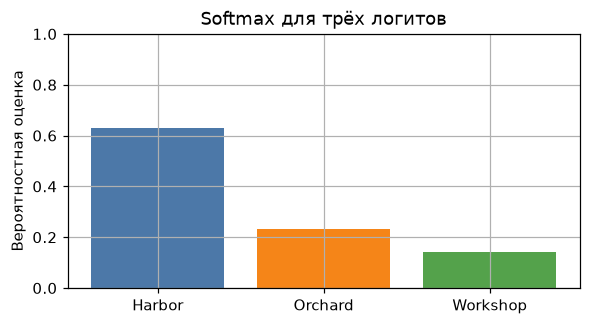

In [4]:
logits_example = torch.tensor([2.0, 1.0, 0.5])
probabilities_example = torch.softmax(logits_example, dim=0)
manual_loss = -math.log(float(probabilities_example[0]))
torch_loss = nn.CrossEntropyLoss()(logits_example.unsqueeze(0), torch.tensor([0]))
shifted_probabilities = torch.softmax(logits_example + 10.0, dim=0)
print("Softmax:", probabilities_example.numpy().round(4))
print(f"Сумма вероятностей: {probabilities_example.sum():.6f}")
print(f"Потеря вручную: {manual_loss:.6f}; PyTorch: {torch_loss.item():.6f}")
print("Softmax не меняется после общего сдвига логитов:", torch.allclose(probabilities_example, shifted_probabilities))
assert torch.isclose(probabilities_example.sum(), torch.tensor(1.0))
assert math.isclose(manual_loss, torch_loss.item(), rel_tol=1e-6)
assert torch.allclose(probabilities_example, shifted_probabilities)

plt.figure(figsize=(6, 3))
plt.bar(CLASS_NAMES, probabilities_example.numpy(), color=["#4c78a8", "#f58518", "#54a24b"])
plt.ylim(0, 1)
plt.ylabel("Вероятностная оценка")
plt.title("Softmax для трёх логитов")
plt.show()


### Шаг 2.2. Эталонное чтение результата классификатора

`SimpleClassifier` содержит `Linear(input_dim, hidden_dim)`, `ReLU` и `Linear(hidden_dim, output_dim)`; `forward` возвращает необработанные логиты. Потеря на учебном наборе должна уменьшиться. Для новых документов `new_document_logits` имеет форму `(B, 3)`, а `argmax(dim=1)` выбирает наибольший логит из трёх классов в каждой из `B` строк.


### Маршрут §2.2: собрать и проверить классификатор

**Зачем.** Классификатор должен по одной BoW-строке выбрать один из классов `Harbor`, `Orchard`, `Workshop`.

**Наблюдайте.** Harbor-модель имеет ту же архитектуру и ход обучения, но её темы и численные результаты не являются ответом для Greenfield.

**Порядок.** В конструкторе создайте первый линейный слой от длины BoW к 24 скрытым признакам, ReLU и второй линейный слой к трём классам. В `forward` примените их слева направо и верните необработанные логиты.

**Не меняйте.** Не добавляйте Softmax в `forward`, не меняйте `torch.long` у меток и не переписывайте готовые 800 шагов обучения.

**Что запустить.** Следующую ячейку обучения и чтения новых документов.

**Готово, если.** Поток имеет форму `(12, 48) → (12, 24) → (12, 3)`, loss уменьшается, а `new_document_logits` имеет форму `(3, 3)`.

**Если не получилось.** Ошибка форм обычно означает, что `input_dim` не равен длине BoW. Ошибка типа метки означает, что `LABELS` должны иметь тип `torch.long`. `argmax(dim=1)` выбирает класс внутри каждой строки, а не между документами.

**Что записать.** Начальную и финальную loss, форму логитов, смысл `dim=1` и ограничение: уменьшение train loss не доказывает обобщение.


In [5]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc2(self.relu(self.fc1(x)))


Форма classifier_model.fc1.weight: (24, 48)


Потеря: 1.1112 -> 0.0060
Формы потока: (12, 48) -> (12, 24) -> (12, 3)
Форма логитов: (3, 3)
harbor lights guide boats -> Harbor
ripe apples fill baskets -> Orchard
tools repair engines -> Workshop


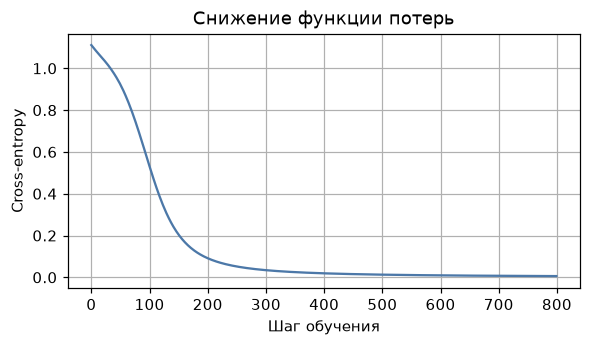

In [6]:
torch.manual_seed(SEED)
classifier_model = SimpleClassifier(input_dim=len(vocabulary), hidden_dim=24, output_dim=len(CLASS_NAMES))
print("Форма classifier_model.fc1.weight:", tuple(classifier_model.fc1.weight.shape))
assert tuple(classifier_model.fc1.weight.shape) == (24, len(vocabulary))
criterion = nn.CrossEntropyLoss()
classifier_optimizer = torch.optim.SGD(classifier_model.parameters(), lr=0.05)
classifier_losses = []
classifier_model.train()
for _ in range(800):
    classifier_optimizer.zero_grad()
    logits = classifier_model(document_vectors)
    classifier_loss = criterion(logits, LABELS)
    classifier_loss.backward()
    classifier_optimizer.step()
    classifier_losses.append(float(classifier_loss.detach()))

classifier_model.eval()
NEW_DOCS = classification_data["new_documents"]
new_document_vectors = torch.tensor([doc_to_bow(doc, vocabulary) for doc in NEW_DOCS], dtype=torch.float32)
with torch.no_grad():
    hidden_vectors = classifier_model.relu(classifier_model.fc1(document_vectors))
    new_document_logits = classifier_model(new_document_vectors)
    predicted_ids = torch.argmax(new_document_logits, dim=1)
print(f"Потеря: {classifier_losses[0]:.4f} -> {classifier_losses[-1]:.4f}")
print("Формы потока:", tuple(document_vectors.shape), "->", tuple(hidden_vectors.shape), "->", (len(DOCS), len(CLASS_NAMES)))
print("Форма логитов:", tuple(new_document_logits.shape))
assert tuple(hidden_vectors.shape) == (len(DOCS), 24)
assert tuple(new_document_logits.shape) == (len(NEW_DOCS), len(CLASS_NAMES))
for document, class_id in zip(NEW_DOCS, predicted_ids.tolist()):
    print(f"{document} -> {CLASS_NAMES[class_id]}")

plt.figure(figsize=(6, 3))
plt.plot(classifier_losses, color="#4c78a8")
plt.xlabel("Шаг обучения")
plt.ylabel("Cross-entropy")
plt.title("Снижение функции потерь")
plt.show()


**Эталонный вывод 2.** `CrossEntropyLoss` принимает логиты и выполняет устойчивое объединение softmax с отрицательным логарифмом. У новых документов `new_document_logits` имеет форму `(B, 3)`: первая ось перечисляет документы, а вторая — классы. Поэтому `argmax(dim=1)` выбирает лучший класс отдельно для каждой строки.


### Разбор 2: как читать результат

Классификатор превращает BoW в три логита; `argmax(dim=1)` выбирает один класс в каждой строке. Уменьшение loss показывает подгонку учебных данных, но не гарантирует качество на новых текстах. Результат относится только к Harbor Town: сопоставьте ход действий со student, но не переносите эти слова и числа в Greenfield-паспорт.


## 3. Skip-gram и эмбеддинги

Для объяснения выберите §3 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Сначала создайте направленные пары «центр — контекст», затем передайте индексы центральных слов в `nn.Embedding` и предскажите индекс контекста. Слой хранит плотный вектор для каждого токена; это статическое представление, поэтому разные значения одного слова не разделяются.


### Маршрут §3: от соседей слова к эмбеддингам

**Зачем.** Skip-gram учит плотный вектор слова по его соседям, поэтому можно сравнить локальные окружения, а не только совпадение букв.

**Наблюдайте.** Harbor example показывает тот же поток «пары → индексы → embedding → соседи» для слова `sailor`.

**Порядок.** 1) для каждого центрального токена перечислите все токены окна радиуса 2, кроме него самого; 2) создайте слой `nn.Embedding` и линейный выход к размеру словаря; 3) в `forward` получите embedding центра и логиты контекста; 4) нормируйте все строки векторов, вычислите косинусные оценки и исключите само слово-запрос.

**Не меняйте.** Корпус, seed, готовый цикл обучения и число ближайших соседей.

**Что запустить.** Следующую ячейку, которая создаёт индексы, обучает модель и рисует двумерную проекцию.

**Готово, если.** Получено 156 направленных пар; поток имеет вид `center_ids (156,) → embedding (156, 12) → logits (156, 17)`; для `sailor` выведены три соседа, но само слово не попало в этот список.

**Если не получилось.** Самопара означает, что не исключен индекс центра. Ошибка размера выходного слоя означает, что он должен иметь столько выходов, сколько токенов в `embedding_vocabulary`. Положение точек на PCA-графике не является буквальной картой значений слов.

**Что записать.** Один наблюдаемый сосед, общий локальный контекст и ограничение малого корпуса.


In [7]:
def make_skipgram_pairs(tokens: list[str], window_size: int) -> list[tuple[str, str]]:
    pairs: list[tuple[str, str]] = []
    for center_index, center_token in enumerate(tokens):
        left = max(0, center_index - window_size)
        right = min(len(tokens), center_index + window_size + 1)
        for context_index in range(left, right):
            if context_index != center_index:
                pairs.append((center_token, tokens[context_index]))
    return pairs


class SkipGramModel(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center_ids: torch.Tensor) -> torch.Tensor:
        return self.output(self.embedding(center_ids))


def nearest_words(word: str, vocabulary: dict[str, int], vectors: torch.Tensor, top_k: int = 3):
    normalized = F.normalize(vectors, dim=1)
    scores = normalized @ normalized[vocabulary[word]]
    ordered_ids = torch.argsort(scores, descending=True).tolist()
    inverse_vocabulary = {index: token for token, index in vocabulary.items()}
    return [(inverse_vocabulary[index], float(scores[index])) for index in ordered_ids if index != vocabulary[word]][:top_k]


Токенов: 54; пар: 156; словарь: 17
Первые направленные пары: [('the', 'sailor'), ('the', 'watches'), ('sailor', 'the'), ('sailor', 'watches'), ('sailor', 'the'), ('watches', 'the')]


Ближайшие слова к 'sailor': [('captain', 0.62), ('ship', 0.499), ('lighthouse', 0.403)]
Ближайшие слова к 'captain': [('sailor', 0.62), ('lighthouse', 0.41), ('bell', 0.409)]


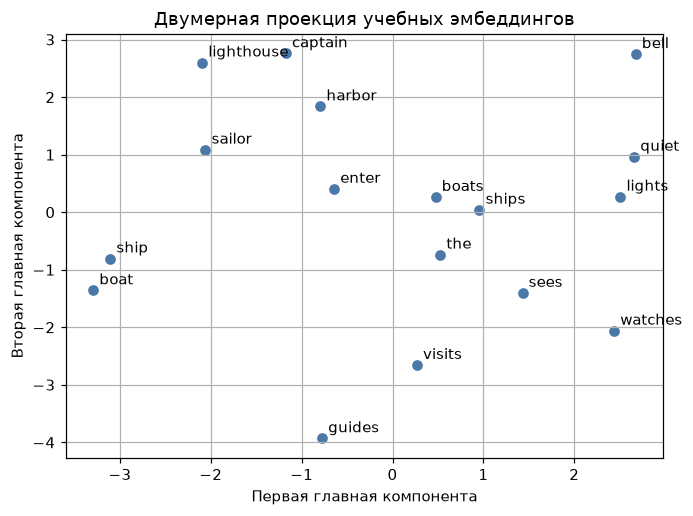

In [8]:
embedding_data = SCENARIO["embedding"]
embedding_lines = embedding_data["lines"]
embedding_tokens = [token for line in embedding_lines for token in tokenize(line)]
embedding_vocabulary = build_vocabulary(embedding_lines)
skipgram_pairs = [
    pair
    for line in embedding_lines
    for pair in make_skipgram_pairs(tokenize(line), window_size=embedding_data["window_size"])
]
center_ids = torch.tensor([embedding_vocabulary[center] for center, _ in skipgram_pairs], dtype=torch.long)
context_ids = torch.tensor([embedding_vocabulary[context] for _, context in skipgram_pairs], dtype=torch.long)
print(f"Токенов: {len(embedding_tokens)}; пар: {len(skipgram_pairs)}; словарь: {len(embedding_vocabulary)}")
print("Первые направленные пары:", skipgram_pairs[:6])
assert all(center != context for center, context in skipgram_pairs)

torch.manual_seed(SEED)
skipgram_model = SkipGramModel(len(embedding_vocabulary), embedding_dim=embedding_data["embedding_dim"])
skipgram_optimizer = torch.optim.Adam(skipgram_model.parameters(), lr=embedding_data["learning_rate"])
skipgram_model.train()
for _ in range(embedding_data["steps"]):
    skipgram_optimizer.zero_grad()
    skipgram_loss = nn.CrossEntropyLoss()(skipgram_model(center_ids), context_ids)
    skipgram_loss.backward()
    skipgram_optimizer.step()

skipgram_model.eval()
embeddings = skipgram_model.embedding.weight.detach()
for query_word in embedding_data["query_words"]:
    print(f"Ближайшие слова к {query_word!r}:", [(word, round(score, 3)) for word, score in nearest_words(query_word, embedding_vocabulary, embeddings)])

matrix = embeddings.numpy()
centered = matrix - matrix.mean(axis=0, keepdims=True)
_, _, right_vectors = np.linalg.svd(centered, full_matrices=False)
coordinates = centered @ right_vectors[:2].T
inverse_embedding_vocabulary = {index: token for token, index in embedding_vocabulary.items()}
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(coordinates[:, 0], coordinates[:, 1], color="#4c78a8")
for index, point in enumerate(coordinates):
    ax.annotate(inverse_embedding_vocabulary[index], point, xytext=(4, 4), textcoords="offset points")
ax.set_title("Двумерная проекция учебных эмбеддингов")
ax.set_xlabel("Первая главная компонента")
ax.set_ylabel("Вторая главная компонента")
plt.show()


**Эталонный вывод 3.** Близкие векторы могут появиться у слов с похожими локальными контекстами, например у ролей города в этом профиле. Это наблюдение относится только к выбранным предложениям: малый корпус не покрывает многозначность и реальное разнообразие языка.


### Разбор 3: как читать результат

Близкие векторы возникают у слов с похожими соседями в этом маленьком корпусе. Такое сходство — наблюдение о локальной статистике, а не доказательство синонимии или общего знания языка. Результат относится только к Harbor Town: сопоставьте ход действий со student, но не переносите эти слова и числа в Greenfield-паспорт.


## 4. Подсловная токенизация BPE

Для объяснения выберите §4 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Эта символьная учебная BPE начинает с символов, считает соседние пары и последовательно сливает самые частые. Сохраняйте различие между частотой слова, частотой пары и упорядоченным списком `merges`; префикс `_` отмечает начало слова, а неизвестный символ заменяется на `<UNK>`.


### Маршрут §4: обучить и применить BPE

**Зачем.** Символьный BPE помогает представить новую словоформу как известные части, когда цельного слова нет в словаре.

**Наблюдайте.** Harbor example использует те же пять функций на `sailboat7`; правила и части слова отличаются от Greenfield по корпусу.

**Порядок.** 1) сохраните каждую словоформу как символы с `_` в начале и её частоту; 2) посчитайте соседние пары с весом частоты словоформы; 3) замените только точные соседние токены выбранной пары; 4) повторяйте подсчёт и слияние до лимита словаря; 5) при применении добавьте `_`, замените неизвестный символ на `<UNK>` и исполните `merges` по порядку.

**Не меняйте.** Лимит `28`, порядок уже выученных `merges` и контрольную ячейку.

**Что запустить.** Следующую ячейку, которая печатает первые правила и сегментации.

**Готово, если.** Число BPE-токенов не больше 28; слово `sailboat7` содержит `<UNK>` в результате сегментации.

**Если не получилось.** `_` обозначает начало слова. `<UNK>` — неизвестный символ BPE; `<unk>` строчными буквами появится только в Count LM как неизвестная цель. Если правила дают другой результат, проверьте, что они применяются в исходном порядке.

**Что записать.** Почему частота целой словоформы влияет на пару, что показывает `<UNK>` и почему порядок правил важен.


In [9]:
def initialize_vocabulary(corpus: list[str]):
    vocabulary: dict[str, int] = defaultdict(int)
    charset: set[str] = set()
    for word in corpus:
        characters = list("_" + word)
        charset.update(characters)
        vocabulary[" ".join(characters)] += 1
    return dict(vocabulary), charset


def get_pair_counts(vocabulary: dict[str, int]):
    pair_counts: dict[tuple[str, str], int] = defaultdict(int)
    for tokenized_word, word_count in vocabulary.items():
        word_tokens = tokenized_word.split()
        for i in range(len(word_tokens) - 1):
            pair_counts[(word_tokens[i], word_tokens[i + 1])] += word_count
    return dict(pair_counts)


def merge_pair(vocabulary: dict[str, int], pair: tuple[str, str]):
    bigram = re.escape(" ".join(pair))
    pattern = re.compile(r"(?<!\S)" + bigram + r"(?!\S)")
    return {pattern.sub("".join(pair), word): count for word, count in vocabulary.items()}


def byte_pair_encoding(corpus: list[str], vocab_size: int):
    vocabulary, charset = initialize_vocabulary(corpus)
    tokens = set(charset)
    merges: list[tuple[str, str]] = []
    while len(tokens) < vocab_size:
        pair_counts = get_pair_counts(vocabulary)
        if not pair_counts:
            break
        pair = max(pair_counts, key=pair_counts.get)
        merged_token = "".join(pair)
        if merged_token in tokens:
            break
        vocabulary = merge_pair(vocabulary, pair)
        merges.append(pair)
        tokens.add(merged_token)
    return vocabulary, merges, charset, tokens


def tokenize_word(word: str, merges: list[tuple[str, str]], charset: set[str], unk_token: str = "<UNK>"):
    word_tokens = [character if character in charset else unk_token for character in "_" + word.lower()]
    for left, right in merges:
        index = 0
        while index < len(word_tokens) - 1:
            if word_tokens[index : index + 2] == [left, right]:
                word_tokens[index : index + 2] = [left + right]
            else:
                index += 1
    return word_tokens


In [10]:
bpe_data = SCENARIO["bpe"]
bpe_corpus = [token for text in bpe_data["corpus"] for token in tokenize(text)]
bpe_vocabulary, merges, charset, bpe_tokens = byte_pair_encoding(bpe_corpus, bpe_data["vocab_size"])
print(f"Размер начального алфавита: {len(charset)}")
print(f"Размер словаря BPE: {len(bpe_tokens)}; число слияний: {len(merges)}")
print("Шаг | сливаемая пара")
for step, pair in enumerate(merges[:10], start=1):
    print(f"{step:3d} | {pair[0]!r} + {pair[1]!r}")
for word in bpe_data["probe_words"]:
    print(f"{word:18s} -> {tokenize_word(word, merges, charset)}")
assert len(bpe_tokens) <= bpe_data["vocab_size"]
assert "<UNK>" in tokenize_word(bpe_data["probe_words"][-1], merges, charset)


Размер начального алфавита: 17
Размер словаря BPE: 28; число слияний: 11
Шаг | сливаемая пара
  1 | 'o' + 'r'
  2 | 'h' + 'a'
  3 | 'ha' + 'r'
  4 | '_' + 'har'
  5 | '_har' + 'b'
  6 | '_harb' + 'or'
  7 | '_' + 's'
  8 | '_s' + 'a'
  9 | '_sa' + 'i'
 10 | '_sai' + 'l'
harbor             -> ['_harbor']
sailboat7          -> ['_sail', 'b', 'o', 'a', 't', '<UNK>']


**Эталонный вывод 4.** Частота пары отражает число её появлений в корпусе, поэтому повторяющееся слово имеет больший вклад. Символ, отсутствующий в алфавите, превращается в `<UNK>`. Каждое слияние меняет будущие соседние пары; другой порядок создаёт другой токенизатор.


### Разбор 4: как читать результат

Частые словоформы сильнее влияют на частоту пары. `<UNK>` означает неизвестный символ BPE, а последовательность `merges` нельзя переставить, потому что каждое слияние меняет следующие соседние пары. Результат относится только к Harbor Town: сопоставьте ход действий со student, но не переносите эти слова и числа в Greenfield-паспорт.


## 5. Счётная триграммная языковая модель

Для объяснения выберите §5 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Триграмма оценивает следующее слово по двум предыдущим. Реализуйте отдельно хранение частот, поиск самого длинного доступного контекста и сглаженную вероятность; не смешивайте общий смысл $P$, несглаженную оценку $P_{\mathrm{MLE}}$ и реализованную $P_{+1}$.


### Маршрут §5: посчитать продолжения и вероятность

**Зачем.** Count LM отвечает на вопрос: какое слово чаще всего продолжает левый контекст и с какой сглаженной вероятностью?

**Наблюдайте.** Harbor example хранит такие же три уровня счётчиков, но продолжает контекст `the harbor`, а не Greenfield-контекст.

**Порядок.** 1) создайте отдельные словари счётчиков для униграмм, биграмм и триграмм; 2) в `train` заполните их скользящими окнами; 3) для прогноза ищите контекст длины 2, затем 1, затем 0; 4) для жадного выбора используйте сырые частоты; 5) для `get_probability` и PPL примените add-one сглаживание; 6) при генерации добавляйте найденный токен к текущей истории.

**Не меняйте.** `n=3`, токены train/test и готовую проверочную ячейку.

**Что запустить.** Следующую ячейку с известным и незнакомым контекстом, нормировкой и жадным продолжением.

**Готово для §5, если.** Контекст `['the', 'harbor']` продолжается словом `bell`; сумма сглаженных вероятностей равна 1, неизвестная цель имеет положительную вероятность. Конечную PPL проверьте первой ячейкой §6: она использует эти же вероятности на отдельной тестовой последовательности.

**Если не получилось.** Незнакомый контекст запускает backoff, а неизвестная цель заменяется на `<unk>`; это разные случаи. Не используйте сглаженные вероятности для `predict_next_token`: он читает самый частый токен из `Counter`.

**Что записать.** Порядок backoff, роль сглаживания для PPL и ограничение: триграмма видит не более двух предыдущих слов.


In [11]:
class CountLanguageModel:
    def __init__(self, n: int):
        if n < 1:
            raise ValueError("n должно быть не меньше 1.")
        self.n = n
        self.ngram_counts: list[dict[tuple[str, ...], Counter[str]]] = [defaultdict(Counter) for _ in range(n)]
        self.total_unigrams = 0
        # <unk> занимает отдельную позицию: все отсутствующие в обучении токены
        # получают одну и ту же, но строго положительную вероятность.
        self.vocabulary: set[str] = {"<unk>"}

    def predict_next_token(self, context: list[str] | tuple[str, ...]):
        for order in range(self.n, 1, -1):
            if len(context) >= order - 1:
                key = tuple(context[-(order - 1) :])
                counts = self.ngram_counts[order - 1].get(key)
                if counts:
                    return counts.most_common(1)[0][0]
        unigram_counts = self.ngram_counts[0].get((), Counter())
        return unigram_counts.most_common(1)[0][0] if unigram_counts else None

    def get_probability(self, token: str, context: list[str] | tuple[str, ...]) -> float:
        # Возвращает сглаженную вероятность из самого длинного известного контекста.
        token = token if token in self.vocabulary else "<unk>"
        vocab_size = len(self.vocabulary)
        for order in range(self.n, 1, -1):
            if len(context) >= order - 1:
                key = tuple(context[-(order - 1) :])
                counts = self.ngram_counts[order - 1].get(key)
                # Если контекст наблюдался, add-one сглаживание определяет
                # распределение для всех токенов словаря и сохраняет его нормировку.
                if counts:
                    return (counts[token] + 1) / (sum(counts.values()) + vocab_size)
        unigram_counts = self.ngram_counts[0].get((), Counter())
        return (unigram_counts[token] + 1) / (self.total_unigrams + vocab_size)


def train(model: CountLanguageModel, tokens: list[str]) -> None:
    model.total_unigrams = len(tokens)
    model.vocabulary = set(tokens) | {"<unk>"}
    for order in range(1, model.n + 1):
        counts = model.ngram_counts[order - 1]
        for index in range(len(tokens) - order + 1):
            context = tuple(tokens[index : index + order - 1])
            next_token = tokens[index + order - 1]
            counts[context][next_token] += 1


def generate_text(model: CountLanguageModel, context: list[str], num_tokens: int) -> str:
    generated = list(context)
    for _ in range(num_tokens):
        next_token = model.predict_next_token(generated)
        if next_token is None:
            break
        generated.append(next_token)
    return " ".join(generated)


def compute_perplexity(model: CountLanguageModel, tokens: list[str], context_size: int) -> float:
    if not tokens:
        return float("inf")
    total_log_probability = 0.0
    for index, token in enumerate(tokens):
        context = tokens[max(0, index - context_size) : index]
        total_log_probability += math.log(model.get_probability(token, context))
    return math.exp(-total_log_probability / len(tokens))


In [12]:
lm_data = SCENARIO["language_model"]
lm_train_tokens = tokenize(lm_data["train_text"])
lm_test_tokens = tokenize(lm_data["test_text"])

count_lm = CountLanguageModel(n=lm_data["n"])
train(count_lm, lm_train_tokens)
known_context = lm_data["known_context"]
unknown_context = lm_data["unknown_context"]
print("Знакомый контекст:", known_context, "->", count_lm.predict_next_token(known_context))
print("Незнакомый контекст:", unknown_context, "->", count_lm.predict_next_token(unknown_context))
print("P(unknown | unseen context) =", f"{count_lm.get_probability('unknown', unknown_context):.8f}")
probability_sum = sum(count_lm.get_probability(token, known_context) for token in count_lm.vocabulary)
print(f"Сумма P(token | знакомый контекст): {probability_sum:.12f}")
print("Продолжение:", generate_text(count_lm, lm_data["generation_context"], lm_data["generation_length"]))
assert count_lm.get_probability("unknown", unknown_context) > 0
assert math.isclose(probability_sum, 1.0, rel_tol=1e-12, abs_tol=1e-12)


Знакомый контекст: ['the', 'harbor'] -> bell
Незнакомый контекст: ['silent', 'harbor'] -> bell
P(unknown | unseen context) = 0.05555556
Сумма P(token | знакомый контекст): 1.000000000000
Продолжение: the harbor bell rings at dawn the


**Эталонный вывод 5.** Модель сначала ищет триграммный переход, затем биграммный и в конце униграммный контекст. На выбранном наблюдавшемся уровне сглаживание выделяет вероятность каждому словарному токену, поэтому логарифм вероятности определён. Триграмма видит не более двух предыдущих токенов и не удерживает дальние зависимости.


### Разбор 5: как читать результат

Модель пробует триграммный, затем биграммный и униграммный контекст. Add-one даёт положительные вероятности для PPL, но триграмма использует только два последних слова и не помнит дальний контекст. Результат относится только к Harbor Town: сопоставьте ход действий со student, но не переносите эти слова и числа в Greenfield-паспорт.


## 6. Перплексия, ROUGE и Elo

Для объяснения выберите §6 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Перплексия оценивает вероятность тестовых токенов, ROUGE — перекрытие с эталоном, а Elo — попарное предпочтение. Сначала назовите входы и диапазон каждой метрики: эти числа отвечают на разные вопросы и не заменяют друг друга.


In [13]:
perplexity = compute_perplexity(count_lm, lm_test_tokens, context_size=count_lm.n - 1)
print(f"Перплексия на тестовой последовательности: {perplexity:.2f}")
assert math.isfinite(perplexity)


Перплексия на тестовой последовательности: 5.92


### Маршрут §6: измерить разные стороны качества

**Зачем.** PPL, ROUGE, Лайкерт и Elo отвечают на разные вопросы; одной цифрой качество текста здесь не измеряется.

**Наблюдайте.** Harbor example применяет ровно те же метрики к своим кандидату, эталону и матчам; Greenfield-ответы остаются отдельными.

**Порядок.** 1) токенизируйте кандидат и эталон, сформируйте `Counter` n-грамм; 2) для ROUGE-N сложите минимумы кратностей; 3) для LCS заполните таблицу динамического программирования; 4) соедините точность и полноту в ROUGE-L; 5) вычислите ожидаемый балл Elo; 6) обновите оба рейтинга из ожиданий до изменения пары.

**Не меняйте.** Эталон, кандидаты, журнал матчей, `beta=8` и начальные рейтинги 1500.

**Что запустить.** Следующую ячейку с функциями метрик, а затем готовые ячейки ROUGE и Elo. PPL уже напечатана непосредственно выше.

**Готово, если.** PPL конечна; все ROUGE лежат в `[0, 1]`, кандидаты A и B дают разные значения, а сумма трёх Elo-рейтингов остаётся `4500`.

**Если не получилось.** `generated` — кандидат, `reference` — эталон. Повторы нужно учитывать через `min`, а не через множество. При Elo рассчитайте `expected_left` и `expected_right` до изменения рейтинга первого участника.

**Что записать.** Почему overlap не доказывает истинность; какую сильную сторону и какое ограничение имеет PPL; зачем нужны люди и почему Elo требует многих сравнений.


In [14]:
def ngram_counter(text: str, n: int) -> Counter[tuple[str, ...]]:
    return Counter(make_ngrams(tokenize(text), n))


def rouge_n_recall(generated: str, reference: str, n: int) -> float:
    reference_counts = ngram_counter(reference, n)
    generated_counts = ngram_counter(generated, n)
    total = sum(reference_counts.values())
    if total == 0:
        return 0.0
    overlap = sum(min(count, generated_counts[gram]) for gram, count in reference_counts.items())
    return overlap / total


def lcs_length(left: list[str], right: list[str]) -> int:
    table = [[0] * (len(right) + 1) for _ in range(len(left) + 1)]
    for i, left_token in enumerate(left, start=1):
        for j, right_token in enumerate(right, start=1):
            if left_token == right_token:
                table[i][j] = table[i - 1][j - 1] + 1
            else:
                table[i][j] = max(table[i - 1][j], table[i][j - 1])
    return table[-1][-1]


def rouge_l(generated: str, reference: str, beta: float = 8.0) -> float:
    generated_tokens, reference_tokens = tokenize(generated), tokenize(reference)
    if not generated_tokens or not reference_tokens:
        return 0.0
    common = lcs_length(generated_tokens, reference_tokens)
    recall = common / len(reference_tokens)
    precision = common / len(generated_tokens)
    if recall + beta**2 * precision == 0:
        return 0.0
    return (1 + beta**2) * recall * precision / (recall + beta**2 * precision)


def expected_score(rating_a: float, rating_b: float) -> float:
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


def update_elo(rating: float, actual_score: float, expected: float, k: float = 32) -> float:
    return rating + k * (actual_score - expected)


Модель | ROUGE-1 | ROUGE-2 | ROUGE-L
A      |   1.000 |   0.600 |   0.831
B      |   0.167 |   0.000 |   0.167


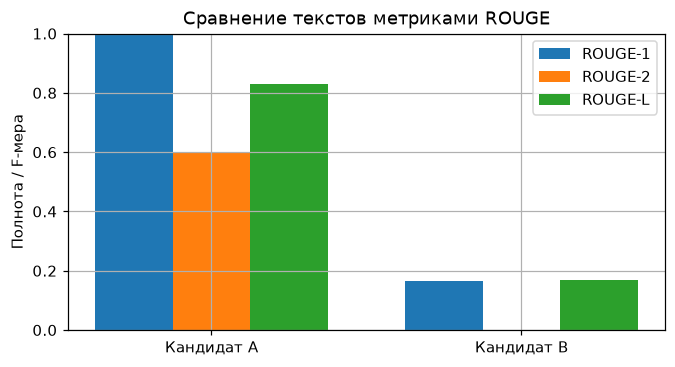

In [15]:
evaluation_data = SCENARIO["evaluation"]
reference = evaluation_data["reference"]
candidate_by_name = {item["name"]: item["text"] for item in evaluation_data["candidates"]}

rows = []
for name, candidate in candidate_by_name.items():
    rows.append((name, rouge_n_recall(candidate, reference, 1), rouge_n_recall(candidate, reference, 2), rouge_l(candidate, reference)))
print("Модель | ROUGE-1 | ROUGE-2 | ROUGE-L")
for name, r1, r2, rl in rows:
    print(f"{name:6s} | {r1:7.3f} | {r2:7.3f} | {rl:7.3f}")
assert all(0 <= value <= 1 for _, *values in rows for value in values)

names = [row[0] for row in rows]
x = np.arange(len(names))
plt.figure(figsize=(7, 3.5))
plt.bar(x - 0.25, [row[1] for row in rows], width=0.25, label="ROUGE-1")
plt.bar(x, [row[2] for row in rows], width=0.25, label="ROUGE-2")
plt.bar(x + 0.25, [row[3] for row in rows], width=0.25, label="ROUGE-L")
plt.xticks(x, ["Кандидат " + name for name in names])
plt.ylim(0, 1)
plt.ylabel("Полнота / F-мера")
plt.title("Сравнение текстов метриками ROUGE")
plt.legend()
plt.show()


In [16]:
matches = [(left, right, float(left_score)) for left, right, left_score in evaluation_data["elo_matches"]]
ratings = {name: 1500.0 for name in evaluation_data["elo_names"]}
for left, right, left_score in matches:
    expected_left = expected_score(ratings[left], ratings[right])
    expected_right = 1 - expected_left
    ratings[left] = update_elo(ratings[left], left_score, expected_left)
    ratings[right] = update_elo(ratings[right], 1 - left_score, expected_right)
print("Итоговые Elo:")
for name, rating in sorted(ratings.items(), key=lambda item: item[1], reverse=True):
    print(f"{name}: {rating:.1f}")
assert math.isclose(sum(ratings.values()), 4500.0, rel_tol=1e-12)


Итоговые Elo:


Orchard-LM: 1501.5
Harbor-LM: 1499.3
Workshop-LM: 1499.2


### Шкала Лайкерта для ручной оценки

| Балл | Интерпретация |
| ---: | --- |
| -2 | Критерий практически не выполнен. |
| -1 | Критерий выполнен с существенными недостатками. |
| 0 | Результат приемлем, но без убедительных достоинств. |
| 1 | Критерий выполнен хорошо. |
| 2 | Критерий выполнен полностью и убедительно. |

**Эталонный вывод 6.** ROUGE измеряет лексическое совпадение и не проверяет истинность утверждений. Elo становится устойчивее при множестве сравнений с разными подсказками и оценщиками. Перплексия хорошо оценивает вероятность тестовой последовательности, но её нельзя напрямую сравнивать между разными токенизациями и задачами.


### Разбор 6: как читать результат

ROUGE измеряет совпадение формулировок, но не проверяет факты. PPL честно проверяет, насколько модель объясняет истинные тестовые токены, однако не оценивает смысл, фактическую точность или качество собственного сгенерированного текста. Лайкерт добавляет человеческое суждение по отдельному критерию, а Elo становится содержательнее лишь после многих сопоставимых матчей. Результат относится только к Harbor Town: сопоставьте ход действий со student, но не переносите эти слова и числа в Greenfield-паспорт.
#### Пример ручной оценки Лайкерта кандидата A

| Критерий | Балл | Короткое обоснование |
| --- | ---: | --- |
| Связность | 1 | Слова образуют короткое читаемое сообщение. |
| Информативность | 0 | Текст почти не добавляет контекста и деталей. |
| Фактологическая точность | 0 | По одному совпадению с эталоном нельзя подтвердить факт. |

Эти три числа — пример аргументированного человеческого суждения, а не вывод из ROUGE и не единственно допустимый ответ.



## Итоговый практический результат: мини-портфолио текстового эксперимента

До этого места вы реализовали шесть связанных тем, но это не один искусственный конвейер: BPE, skip-gram и счётная языковая модель решают разные учебные задачи. Ниже готовая базовая ячейка собирает четыре самостоятельных результата в один понятный отчёт. Она использует готовые объекты предыдущих частей и запускается после их выполнения.

| Раздел лекции | Реализованный компонент | Что показывает итоговый отчёт | Проверка и граница вывода | Как переносить на похожую задачу |
| --- | --- | --- | --- | --- |
| §1 | `tokenize`, бинарный BoW, n-граммы | Токены, известные и OOV-слова, активные признаки и биграммы документа | Нулевой BoW означает отсутствие известных признаков; порядок и частоты не становятся признаками классификатора | Заменить документы, затем заново построить словарь и DTM |
| §2 | `SimpleClassifier` | Логиты, вероятности и тематический класс документа | Форма `(1, 3)`, сумма вероятностей равна 1; это не доказательство качества на новых данных | Подать новые документы и метки, затем переобучить модель |
| §3 | skip-gram и `nearest_words` | Три ближайших по косинусному сходству слова | Запрос не должен попасть в собственный список; близость относится только к малому корпусу | Заменить корпус контекстов и обучить эмбеддинги заново |
| §4 | символьный BPE | Разбиение нового слова на подслова и `<UNK>` для неизвестного символа | `<UNK>` — неизвестный символ BPE, а не неизвестное слово LM | Заменить корпус или размер словаря и обучить новые `merges` |
| §5 | счётная триграммная LM | Жадное продолжение, вероятность следующего токена и PPL тестовой последовательности | Конечная PPL использует teacher forcing; триграмма видит не более двух предыдущих токенов | Заменить обучающую и тестовую последовательности, затем обучить LM заново |
| §6 | PPL, ROUGE, Лайкерт и Elo | PPL, три ROUGE-значения, итог Elo и ручная оценка в паспорте | ROUGE не проверяет истинность, Лайкерт субъективен, Elo требует многих сравнений | Заменить кандидата, эталон и журнал сравнений; интерпретировать метрики вместе |

Полный результат — не только напечатанные числа. После базовой ячейки заполните паспорт: зафиксируйте наблюдение, проверку, ограничение и следующий безопасный шаг адаптации.


### Как завершить мини-портфолио

**Зачем.** Это не новая модель и не новая задача: отчёт собирает четыре уже реализованных результата, чтобы у каждого были вход, вывод, проверка и ограничение.

**Наблюдайте.** Готовая ячейка собирает Harbor-результаты тем же способом. Она показывает формат отчёта, но Greenfield-паспорт заполняется только по student-запуску.

**Готово, если.** Напечатаны девять строк `✓`: форма логитов, нормировка softmax, известные признаки, запрос эмбеддингов, исключение самого слова, `<UNK>` BPE, конечная PPL, диапазон ROUGE и сумма Elo `4500`.

**Что записать.** В паспорте заполните все четыре строки по конкретному выводу отчёта. Укажите вход, наблюдаемый результат, проверенный инвариант, ограничение и одно действие для переноса на похожую задачу.

**Песочница.** Только после базового отчёта разрешено менять значения `CUSTOM_CASE`. Она проверяет OOV и пустой текст, не влияет на базовый результат и не заменяет обязательный паспорт.


In [17]:
portfolio_data = SCENARIO["portfolio"]
PORTFOLIO_CASE = {
    **portfolio_data,
    "perplexity_tokens": lm_test_tokens,
    "candidate": candidate_by_name[portfolio_data["candidate_name"]],
    "reference": reference,
}


def as_tokens(value):
    '''Безопасно приводит строку или последовательность к учебным словным токенам.'''
    if isinstance(value, str):
        return tokenize(value)
    if isinstance(value, (list, tuple)):
        return [token for item in value for token in tokenize(str(item))]
    return []


def bounded_count(value, default=5):
    '''Не даёт необязательной песочнице случайно запросить слишком длинную генерацию.'''
    try:
        return min(max(int(value), 0), 20)
    except (TypeError, ValueError):
        return default


def run_portfolio_case(case, title, strict=False):
    '''Собирает отчёт, не меняя модель, словари, merges или исходные данные.'''
    document = str(case.get("document", ""))
    document_tokens = tokenize(document)
    known_tokens = sorted({token for token in document_tokens if token in vocabulary})
    oov_tokens = sorted({token for token in document_tokens if token not in vocabulary})
    document_bigrams = make_ngrams(document_tokens, 2)
    document_vector = torch.tensor([doc_to_bow(document, vocabulary)], dtype=torch.float32)

    if known_tokens:
        was_training = classifier_model.training
        classifier_model.eval()
        with torch.no_grad():
            document_logits = classifier_model(document_vector)
            document_probabilities = torch.softmax(document_logits, dim=1)
            document_class_id = int(torch.argmax(document_logits, dim=1).item())
        classifier_model.train(was_training)
        classification_message = "Класс выбран по известным бинарным признакам документа."
    else:
        document_logits = None
        document_probabilities = None
        document_class_id = None
        classification_message = "BoW нулевой: у модели нет лексического признака для содержательной классификации."

    query_tokens = as_tokens(case.get("embedding_word", ""))
    embedding_query = query_tokens[0] if len(query_tokens) == 1 else None
    if embedding_query in embedding_vocabulary:
        nearest = nearest_words(embedding_query, embedding_vocabulary, embeddings, top_k=3)
        embedding_message = "Запрос найден в словаре эмбеддингов."
    else:
        nearest = []
        embedding_message = "Запроса нет в словаре эмбеддингов: близкие слова не вычисляются."

    bpe_word = str(case.get("bpe_word", ""))
    if bpe_word:
        bpe_result = tokenize_word(bpe_word, merges, charset)
        bpe_message = "<UNK> здесь означает неизвестный символ, а не неизвестное слово языковой модели."
    else:
        bpe_result = []
        bpe_message = "Пустую строку сегментировать не нужно: в ней нет символов слова."

    lm_context = as_tokens(case.get("lm_context", []))
    num_tokens = bounded_count(case.get("num_tokens", 5))
    predicted_token = count_lm.predict_next_token(lm_context)
    predicted_probability = count_lm.get_probability(predicted_token, lm_context)
    generated_text = generate_text(count_lm, lm_context, num_tokens)
    ppl_tokens = as_tokens(case.get("perplexity_tokens", []))
    portfolio_ppl = compute_perplexity(count_lm, ppl_tokens, context_size=count_lm.n - 1)

    candidate = str(case.get("candidate", ""))
    portfolio_reference = str(case.get("reference", ""))
    rouge_scores = {
        "ROUGE-1": rouge_n_recall(candidate, portfolio_reference, 1),
        "ROUGE-2": rouge_n_recall(candidate, portfolio_reference, 2),
        "ROUGE-L": rouge_l(candidate, portfolio_reference),
    }
    elo_total = sum(ratings.values())
    elo_leader = max(ratings, key=ratings.get)

    report = {
        "classification": {
            "tokens": document_tokens,
            "known_tokens": known_tokens,
            "oov_tokens": oov_tokens,
            "active_features": int(document_vector.sum().item()),
            "logits_shape": tuple(document_logits.shape) if document_logits is not None else None,
            "probability_sum": float(document_probabilities.sum()) if document_probabilities is not None else None,
            "class_name": CLASS_NAMES[document_class_id] if document_class_id is not None else None,
            "message": classification_message,
        },
        "embeddings": {
            "query": embedding_query,
            "nearest": nearest,
            "message": embedding_message,
        },
        "bpe": {"word": bpe_word, "tokens": bpe_result},
        "language_model_and_metrics": {
            "context": lm_context,
            "predicted_token": predicted_token,
            "predicted_probability": predicted_probability,
            "generated_text": generated_text,
            "perplexity": portfolio_ppl,
            "rouge": rouge_scores,
            "elo_leader": elo_leader,
            "elo_total": elo_total,
        },
    }

    print(f"=== {title} ===")
    print("1. BoW + классификатор")
    print("   токены:", document_tokens)
    print("   известные / OOV:", known_tokens, "/", oov_tokens)
    print("   активные признаки:", report["classification"]["active_features"])
    if document_logits is not None:
        print("   logits:", tuple(document_logits.shape), "; вероятности:", document_probabilities[0].numpy().round(4))
        print("   предсказанный класс:", report["classification"]["class_name"])
    print("   ", classification_message)
    print("   биграммы для проверки порядка:", document_bigrams)

    print("2. Skip-gram")
    print("   запрос:", embedding_query)
    print("   ближайшие:", [(word, round(score, 3)) for word, score in nearest])
    print("   ", embedding_message)

    print("3. BPE")
    print(f"   {bpe_word!r} ->", bpe_result)
    print("   ", bpe_message)

    print("4. Count LM + метрики")
    print("   контекст:", lm_context, "->", predicted_token, f"(P={predicted_probability:.6f})")
    print("   жадное продолжение:", generated_text)
    print("   PPL тестовой последовательности:", portfolio_ppl)
    print("   ROUGE:", {name: round(score, 3) for name, score in rouge_scores.items()})
    print(f"   лидер Elo: {elo_leader}; сумма рейтингов: {elo_total:.1f}")

    if strict:
        checks = {
            "логиты имеют форму (1, 3)": report["classification"]["logits_shape"] == (1, 3),
            "вероятности классификатора суммируются к 1": report["classification"]["probability_sum"] is not None and math.isclose(report["classification"]["probability_sum"], 1.0, rel_tol=1e-6, abs_tol=1e-6),
            "базовый документ содержит известные признаки": bool(known_tokens),
            "слово-запрос известно эмбеддингам": embedding_query in embedding_vocabulary,
            "сам запрос исключён из списка соседей": all(word != embedding_query for word, _ in nearest),
            "BPE отмечает неизвестный символ": "<UNK>" in bpe_result,
            "PPL базового теста конечна": math.isfinite(portfolio_ppl),
            "все ROUGE лежат в [0, 1]": all(0 <= score <= 1 for score in rouge_scores.values()),
            "сумма Elo равна 4500": math.isclose(elo_total, 4500.0, rel_tol=1e-12),
        }
        print("Проверки обязательного базового сценария:")
        for check_name, passed in checks.items():
            print(f"   {'✓' if passed else '✗'} {check_name}")
        assert all(checks.values()), "Базовый мини-портфолио не прошёл одну из проверок."
    else:
        print("Диагностика песочницы: отличия от базового случая ожидаемы и не влияют на его проверки.")
    return report


BASELINE_PORTFOLIO = run_portfolio_case(PORTFOLIO_CASE, "Обязательный базовый мини-портфолио", strict=True)
BASELINE_PORTFOLIO_SNAPSHOT = deepcopy(BASELINE_PORTFOLIO)
PORTFOLIO_CASE_SNAPSHOT = deepcopy(PORTFOLIO_CASE)


=== Обязательный базовый мини-портфолио ===
1. BoW + классификатор
   токены: ['harbor', 'lights', 'guide', 'boats']
   известные / OOV: ['boats', 'harbor', 'lights'] / ['guide']
   активные признаки: 3
   logits: (1, 3) ; вероятности: [0.9814 0.0116 0.007 ]
   предсказанный класс: Harbor
    Класс выбран по известным бинарным признакам документа.
   биграммы для проверки порядка: [('harbor', 'lights'), ('lights', 'guide'), ('guide', 'boats')]
2. Skip-gram
   запрос: sailor
   ближайшие: [('captain', 0.62), ('ship', 0.499), ('lighthouse', 0.403)]
    Запрос найден в словаре эмбеддингов.
3. BPE
   'sailboat7' -> ['_sail', 'b', 'o', 'a', 't', '<UNK>']
    <UNK> здесь означает неизвестный символ, а не неизвестное слово языковой модели.
4. Count LM + метрики
   контекст: ['the', 'harbor'] -> bell (P=0.176471)
   жадное продолжение: the harbor bell rings at dawn the
   PPL тестовой последовательности: 5.917567545454195
   ROUGE: {'ROUGE-1': 1.0, 'ROUGE-2': 0.6, 'ROUGE-L': 0.831}
   лидер El

### Эталонный паспорт результата

| Блок результата | Вход и наблюдаемый результат | Проверенный инвариант | Ограничение вывода | Следующий шаг адаптации |
| --- | --- | --- | --- |
| BoW + классификатор | `harbor lights guide boats` даёт ненулевой бинарный вектор, логиты и тематический класс. | Логиты имеют форму `(1, 3)`, а вероятности суммируются к 1. | BoW не хранит порядок и не даёт признака неизвестному слову. | Для новой темы заменить документы и метки, построить новый словарь и переобучить классификатор. |
| Skip-gram | Для `sailor` выведены три слова с наиболее близкими векторами. | Само слово-запрос не попадает в список соседей. | Близость отражает только контексты малого учебного корпуса. | Заменить корпус контекстов и обучить эмбеддинги заново. |
| BPE | В `sailboat7` неизвестный символ даёт отдельный `<UNK>`. | В разбиении присутствует `<UNK>`. | Это неизвестный символ BPE, не вероятностная категория LM. | Обучить `merges` на новом корпусе с выбранным размером словаря. |
| Count LM + метрики | LM продолжает `the harbor`, PPL теста конечна; ROUGE кандидата A показывает лексическое перекрытие, Elo сохраняет сумму 4500. | PPL конечна, ROUGE лежит в `[0, 1]`, Elo сохраняет сумму. | Жадная триграмма не видит дальний контекст; ROUGE не доказывает истинность текста. | Заново обучить LM на новой последовательности и пересчитать метрики для нового кандидата и эталона. |

Возможная ручная оценка кандидата A: связность `1`, информативность `0`, фактологическая точность `0`. Это пример аргументированной оценки, а не единственно верный набор чисел: ROUGE измеряет перекрытие токенов, но не связность и не истинность утверждений.


### Необязательная песочница `CUSTOM_CASE`

Эта ячейка показывает безопасные границы интерфейса: полностью OOV-документ превращается в нулевой BoW, неизвестное слово не ищется среди эмбеддингов, а пустая тестовая последовательность имеет PPL `inf`. Базовый отчёт выше не меняется. Можно заменить только значения словаря `CUSTOM_CASE`; не меняйте функции и не включайте результат песочницы в обязательный паспорт, если это не требуется преподавателем.


In [18]:
# Меняйте только значения этого словаря. Базовый профиль и обученные объекты выше не меняются.
CUSTOM_CASE = deepcopy(SCENARIO["sandbox"])

CUSTOM_PORTFOLIO = run_portfolio_case(CUSTOM_CASE, "Необязательная песочница", strict=False)
baseline_unchanged = BASELINE_PORTFOLIO == BASELINE_PORTFOLIO_SNAPSHOT and PORTFOLIO_CASE == PORTFOLIO_CASE_SNAPSHOT
assert baseline_unchanged
print("Песочница не меняет базовый результат и его входы:", baseline_unchanged)


=== Необязательная песочница ===
1. BoW + классификатор
   токены: ['zephyrs', 'quizzically']
   известные / OOV: [] / ['quizzically', 'zephyrs']
   активные признаки: 0
    BoW нулевой: у модели нет лексического признака для содержательной классификации.
   биграммы для проверки порядка: [('zephyrs', 'quizzically')]
2. Skip-gram
   запрос: unseenword
   ближайшие: []
    Запроса нет в словаре эмбеддингов: близкие слова не вычисляются.
3. BPE
   '' -> []
    Пустую строку сегментировать не нужно: в ней нет символов слова.
4. Count LM + метрики
   контекст: ['silent', 'harbor'] -> bell (P=0.166667)
   жадное продолжение: silent harbor bell rings at
   PPL тестовой последовательности: inf
   ROUGE: {'ROUGE-1': 0.0, 'ROUGE-2': 0.0, 'ROUGE-L': 0.0}
   лидер Elo: Orchard-LM; сумма рейтингов: 4500.0
Диагностика песочницы: отличия от базового случая ожидаемы и не влияют на его проверки.
Песочница не меняет базовый результат и его входы: True
